In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
# from dynamic_routing_analysis import decoding_utils
# from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
# import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget

In [2]:
results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_0/" #context module only
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_500ms_bins_0/"

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_vis_target_0/"
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_aud_target_0/"

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_all_areas_0/" #all units, all areas
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_all_areas_1/" #all units, all areas

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_PL_0/"

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_all_areas_20260910_234254/"

# results_path = r"" #context module, 50units w/ resampling

In [3]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.289.parquet"


session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    # pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    pl.col('is_opto_perturbation').eq(False),
    pl.col('is_injection_perturbation').eq(False),
    pl.col('is_context_naive').eq(False),
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
    'n_engaged_blocks':[],
}

for sel_session in dr_session_list:
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)
    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    good_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2 and n_engaged_blocks>=4')['session_id'].values

In [4]:
savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\cross_temporal_decoding_2026-09-14_context_module"
# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\cross_temporal_decoding_2026-09-10"


In [ ]:
#to save memory loop through each session individually, then save output

# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\cross_temporal_decoding_2026-09-14_context_module"


for sel_session in dr_session_list:

    cross_temporal_decoding_results = {
        'session_id': [],
        'structure': [],
        'bin_centers': [],
        'n_timebins': [],
        'cross_temporal_matrix': []
    }

    results = (
        pl.scan_parquet(results_path)
        .filter(
            # pl.col('structure').eq(sel_structure),
            pl.col('time_aligned_to').eq('stim_start_time'),
            pl.col('session_id').eq(sel_session)
        )
        .with_columns(
            pl.col('bin_center').round(decimals=3),
            pl.col('train_bin_center').round(decimals=3),
            pl.col('test_bin_center').round(decimals=3)
        )
        .sort('bin_center','train_bin_center','test_bin_center')
        .collect()
    )

    if results.shape[0] == 0:
        print(f"No results for session: {sel_session}")
        continue
    
    #find how many timebins there are
    timebins = results.filter(pl.col('is_cross_temporal') == False).select(pl.col('bin_center')).unique()
    n_timebins = timebins.shape[0]

    #loop through each structure
    for structure in results.select(pl.col('structure')).unique()['structure']:
        structure_results = results.filter(pl.col('structure').eq(structure))
        
        #make a matrix to store the cross-temporal results
        cross_temporal_matrix = np.full((n_timebins, n_timebins), np.nan)

        #first get non-cross temporal decoding for each timebin, average across repeats, and add to matrix
        non_cross_temporal_results = structure_results.filter(pl.col('is_cross_temporal') == False)
        for i, timebin in enumerate(timebins['bin_center']):
            mean_result = non_cross_temporal_results.filter(
                (pl.col('bin_center') == timebin) &
                (pl.col('time_aligned_to').eq('stim_start_time'))
            ).select(pl.col('balanced_accuracy_test')).to_numpy().mean()
            cross_temporal_matrix[i, i] = mean_result

        #then get cross temporal decoding for each train-test bin combination, average across repeats, and fill in matrix 
        cross_temporal_results = structure_results.filter(pl.col('is_cross_temporal') == True)
        for i, train_timebin in enumerate(timebins['bin_center']):
            for j, test_timebin in enumerate(timebins['bin_center']):
                if i==j:
                    continue
                mean_result = cross_temporal_results.filter(
                    (pl.col('train_bin_center') == train_timebin) & 
                    (pl.col('test_bin_center') == test_timebin) &
                    (pl.col('train_time_aligned_to').eq('stim_start_time')) &
                    (pl.col('test_time_aligned_to').eq('stim_start_time'))
                ).select(pl.col('balanced_accuracy_test')).to_numpy().mean()
                cross_temporal_matrix[i, j] = mean_result
        if cross_temporal_results.shape[0] > 0:
            cross_temporal_decoding_results['session_id'].append(sel_session)
            cross_temporal_decoding_results['structure'].append(structure)
            cross_temporal_decoding_results['bin_centers'].append(timebins['bin_center'].to_numpy())
            cross_temporal_decoding_results['n_timebins'].append(n_timebins)
            cross_temporal_decoding_results['cross_temporal_matrix'].append(list(cross_temporal_matrix))

    cross_temporal_decoding_results=pd.DataFrame(cross_temporal_decoding_results)
    cross_temporal_decoding_results.to_parquet(f"{savepath}\\cross_temporal_decoding_results_{sel_session}.parquet")

    print(f"Finished processing session: {sel_session}")

Finished processing session: 626791_2022-08-15
Finished processing session: 644864_2023-01-30
Finished processing session: 644864_2023-01-31
No results for session: 644864_2023-02-02
No results for session: 644866_2023-02-07
Finished processing session: 644866_2023-02-08
Finished processing session: 644866_2023-02-09
Finished processing session: 644866_2023-02-10
Finished processing session: 649943_2023-02-13
Finished processing session: 649943_2023-02-14
Finished processing session: 649943_2023-02-15
Finished processing session: 649943_2023-02-16
Finished processing session: 644867_2023-02-20
Finished processing session: 644867_2023-02-22
Finished processing session: 644867_2023-02-23
Finished processing session: 660023_2023-08-09
Finished processing session: 666986_2023-08-15
Finished processing session: 666986_2023-08-17
Finished processing session: 662892_2023-08-22
Finished processing session: 662892_2023-08-23
Finished processing session: 662892_2023-08-24
Finished processing ses

In [ ]:
# cross_temporal_decoding_results

In [ ]:
# np.vstack(list(cross_temporal_matrix))

In [5]:
consolidated_results = (
    pl.scan_parquet(savepath+"\\")
).collect()

In [6]:
# consolidated_results['structure'].unique().to_list()
consolidated_results

session_id,structure,bin_centers,n_timebins,cross_temporal_matrix
str,str,list[f64],i64,list[list[f64]]
"""626791_2022-08-15""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.596811, 0.648003, … 0.657236], [0.624812, 0.641662, … 0.641928], … [0.608097, 0.638604, … 0.642065]]"
"""644864_2023-01-30""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.615608, 0.622345, … 0.642979], [0.598143, 0.61181, … 0.619242], … [0.609506, 0.631824, … 0.665098]]"
"""644864_2023-01-31""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.674556, 0.728886, … 0.730532], [0.72499, 0.750325, … 0.742156], … [0.707403, 0.725576, … 0.762114]]"
"""644866_2023-02-08""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.65835, 0.708962, … 0.695938], [0.690926, 0.699873, … 0.683944], … [0.674516, 0.695318, … 0.697102]]"
"""644866_2023-02-09""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.732208, 0.719842, … 0.738004], [0.705597, 0.704245, … 0.728651], … [0.715495, 0.714487, … 0.740337]]"
…,…,…,…,…
"""759434_2025-02-04""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.757602, 0.735527, … 0.770321], [0.742733, 0.730176, … 0.75982], … [0.740116, 0.745306, … 0.771286]]"
"""759434_2025-02-05""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.634064, 0.643887, … 0.684234], [0.635804, 0.648246, … 0.677916], … [0.668155, 0.665892, … 0.70098]]"
"""759434_2025-02-06""","""context_module""","[-1.45, -1.35, … 5.45]",70,"[[0.708267, 0.707848, … 0.746662], [0.701418, 0.712205, … 0.740962], … [0.713648, 0.722406, … 0.754953]]"


In [7]:
#add subject id (first 6 digits of session_id) to consolidated_results
consolidated_results = consolidated_results.with_columns(
    pl.col('session_id').str.slice(0, 6).alias('subject_id')
)

Text(0, 0.5, 'Train Timebin (s)')

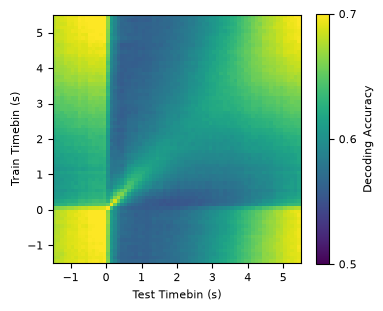

In [55]:
sel_structure='context_module'

# consolidated_results.filter(pl.col('structure').eq(sel_structure))['cross_temporal_matrix']

structure_mean_results=(
    consolidated_results.filter(pl.col('structure').eq(sel_structure))
).to_pandas()

cross_temporal_df = pd.DataFrame({
    'session_id': structure_mean_results['session_id'],
    'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

mean_cross_temporal_matrix=np.nanmean(np.dstack(cross_temporal_df['cross_temporal_matrix'].apply(np.vstack).values), axis=2)

plot_timebins=structure_mean_results['bin_centers'].iloc[0]
binsize=plot_timebins[1]-plot_timebins[0]

#plot heatmap
fig,ax = plt.subplots(figsize=(4,3.25))
im = ax.imshow(mean_cross_temporal_matrix, aspect='equal', origin='lower', cmap='viridis',vmin=0.5,vmax=0.70,
               extent=[plot_timebins.min()-binsize/2, plot_timebins.max()+binsize/2, 
                       plot_timebins.min()-binsize/2, plot_timebins.max()+binsize/2])
cb=fig.colorbar(im, ax=ax, label='Decoding Accuracy', )
#set colorbar ticks
# cb.set_ticks([0.5, 0.55, 0.6, 0.65, 0.7])
cb.set_ticks([0.5, 0.6, 0.7])
ax.set_xlabel('Test Timebin (s)')
ax.set_ylabel('Train Timebin (s)')
# ax.set_title(f'Cross-Temporal Decoding: {sel_structure}')

In [56]:
figsavepath = r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(figsavepath, f"cross_temporal_decoding_matrix_context_module.png"),dpi=300,pad_inches=0.5)

In [9]:
mean_cross_temporal_matrix[20,10] #train, test
mean_cross_temporal_matrix[10,20] #train, test

0.5687091396602115

In [65]:
#find median time to beginning of next trial's quiescent period
all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.289/consolidated/trials.parquet').collect()

all_trials=(
    all_trials.filter(
        pl.col('session_id').is_in(dr_session_list)
    )
    .with_columns(
        (pl.col('quiescent_start_time').shift(-1)).alias('next_quiescent_start_time')
    )
).to_pandas()



In [71]:
median_next_quiescent=np.nanmedian(all_trials['next_quiescent_start_time']-all_trials['stim_start_time'])
median_next_quiescent

4.79356000000007

In [ ]:
# plot all structures
figsavepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\cross_temporal_decoding_2026-09-10_figures\heatmaps"

for sel_structure in consolidated_results['structure'].unique():

    structure_mean_results=(
        consolidated_results.filter(pl.col('structure').eq(sel_structure))
    ).to_pandas()

    cross_temporal_df = pd.DataFrame({
        'session_id': structure_mean_results['session_id'],
        'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
    })
    cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

    n_sessions=cross_temporal_df['session_id'].nunique()
    mean_cross_temporal_matrix=np.nanmean(np.dstack(cross_temporal_df['cross_temporal_matrix'].apply(np.vstack).values), axis=2)

    #plot heatmap
    fig,ax = plt.subplots(figsize=(4,3.25))
    im = ax.imshow(mean_cross_temporal_matrix, aspect='equal', origin='lower', cmap='viridis',vmin=0.5,vmax=0.70,
                extent=[timebins['bin_center'].min()-binsize/2, timebins['bin_center'].max()+binsize/2, 
                        timebins['bin_center'].min()-binsize/2, timebins['bin_center'].max()+binsize/2])
    fig.colorbar(im, ax=ax, label='Decoding Accuracy')
    ax.set_xlabel('Test Timebin (s)')
    ax.set_ylabel('Train Timebin (s)')
    ax.set_title(f'Cross-Temporal Decoding: {sel_structure}  ({n_sessions})')

    fig.savefig(f"{figsavepath}\\{sel_structure}_cross_temporal_decoding.png",dpi=300)
    plt.close(fig)
    print(f"Saved figure for structure: {sel_structure}")

Saved figure for structure: PL
Saved figure for structure: RSPd
Saved figure for structure: RT
Saved figure for structure: ENTl
Saved figure for structure: PCN
Saved figure for structure: VPLpc
Saved figure for structure: LSv
Saved figure for structure: HY
Saved figure for structure: CA3
Saved figure for structure: CA2
Saved figure for structure: MPT
Saved figure for structure: SGN
Saved figure for structure: BST
Saved figure for structure: CP
Saved figure for structure: HPF
Saved figure for structure: AUDpo
Saved figure for structure: PAR
Saved figure for structure: MGd
Saved figure for structure: MGv
Saved figure for structure: VPM
Saved figure for structure: CA1
Saved figure for structure: VAL
Saved figure for structure: TRS
Saved figure for structure: CL
Saved figure for structure: TEa
Saved figure for structure: Eth
Saved figure for structure: LP
Saved figure for structure: VISC
Saved figure for structure: VPMpc
Saved figure for structure: SCiw
Saved figure for structure: SCsg
Sav

Text(0.5, 1.0, 'Cross-Temporal Slice at -0.15s')

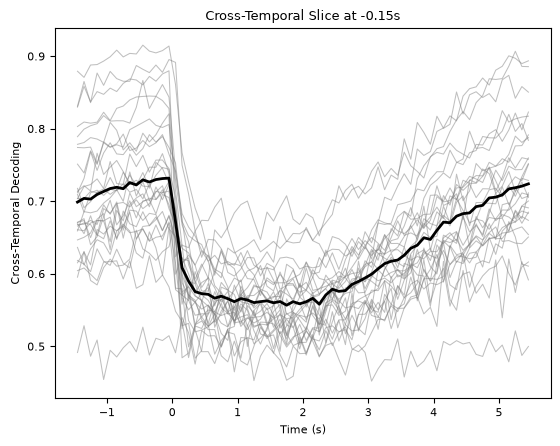

In [ ]:

# sel_bin_center = 0.25
sel_bin_center = -0.15
bin_center_ind = np.where(plot_timebins == sel_bin_center)[0][0]

sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T

fig,ax=plt.subplots(1,1)
ax.plot(plot_timebins, sel_cross_temporal_slice.T, 'grey', alpha=0.5, linewidth=0.75)
ax.plot(plot_timebins, np.nanmean(sel_cross_temporal_slice, axis=0), 'k', linewidth=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cross-Temporal Decoding')
ax.set_title(f'Cross-Temporal Slice at {sel_bin_center}s')

Text(0.3553885473088372, 1.03, 'stimulus')

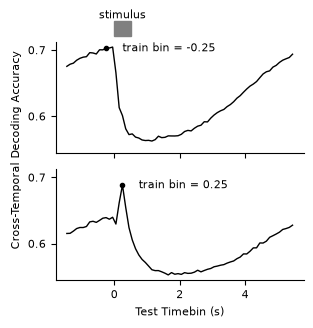

In [10]:
#show 2 train timebins on same plot
bin_center_list=[-0.25, 0.25]
sel_structure='context_module'

structure_mean_results=(
    consolidated_results.filter(pl.col('structure').eq(sel_structure))
).to_pandas()
cross_temporal_df = pd.DataFrame({
    'session_id': structure_mean_results['session_id'],
    'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

fig,ax=plt.subplots(2, 1, figsize=(3, 3),sharex=True,sharey=True)
for bb,sel_bin_center in enumerate(bin_center_list):

    bin_center_ind = np.where(plot_timebins == sel_bin_center)[0][0]
    sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T
    mean_slice=np.nanmean(sel_cross_temporal_slice, axis=0)
    line=ax[bb].plot(plot_timebins, mean_slice, label=sel_structure, linewidth=1, color='k')
    ax[bb].plot(sel_bin_center, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]], '.', color=line[0].get_color())
    ax[bb].text(sel_bin_center+.5, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]], f'train bin = {sel_bin_center:.2f}', color=line[0].get_color(), ha='left', va='center')

    ax[bb].spines['top'].set_visible(False)
    ax[bb].spines['right'].set_visible(False)
    ax[bb].set_yticks([0.6,0.7])
# ax[1].set_ylabel('Cross-Temporal Decoding Accuracy')
#center ylabel across both axes
fig.text(0, 0.6, 'Cross-Temporal Decoding Accuracy', va='center', ha='center', rotation='vertical')
ax[1].set_xlabel('Test Timebin (s)')

fig.tight_layout()

#get display coords corresponding to 0 seconds and 0.5 seconds
fig_coords_0 = ax[0].transData.transform((0.0, 0))
fig_coords_05 = ax[0].transData.transform((0.5, 0))
fig_coords_0 = fig.transFigure.inverted().transform(fig_coords_0)
fig_coords_05 = fig.transFigure.inverted().transform(fig_coords_05)

#plot a box above both subplots from 0-0.5 seconds
fig.patches.extend([
    plt.Rectangle(
        (fig_coords_0[0], 0.98),  # (x, y)
        fig_coords_05[0]-fig_coords_0[0],        # width
        0.05,       # height
        transform=fig.transFigure,
        color='grey',
        # alpha=0.5
    )
])

#plot "stim" above rectangle
fig.text((fig_coords_0[0]+fig_coords_05[0])/2, 1.03, 'stimulus', ha='center', va='bottom')



In [ ]:
figsavepath = r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(figsavepath, f"cross_temporal_decoding_slice_{bin_center_list[0]}_{bin_center_list[1]}_separate_axes.png"),dpi=300,pad_inches=0.5)

[ 0.22419309 -2.16675568] [ 0.25101732 -2.16675568]
[ 0.66510715 -2.16675568] [ 0.69193138 -2.16675568]


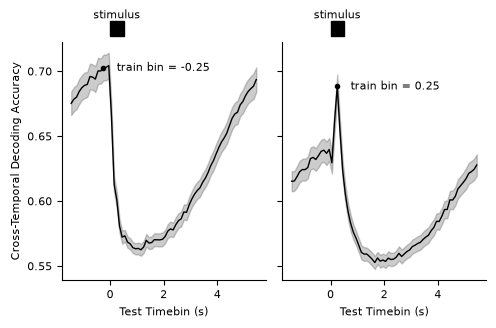

In [ ]:
#show 2 train timebins on same plot
bin_center_list=[-0.25, 0.25]
sel_structure='context_module'

structure_mean_results=(
    consolidated_results.filter(pl.col('structure').eq(sel_structure))
).to_pandas()
cross_temporal_df = pd.DataFrame({
    'session_id': structure_mean_results['session_id'],
    'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

fig,ax=plt.subplots(1, 2, figsize=(5, 3),sharex=True,sharey=True)
for bb,sel_bin_center in enumerate(bin_center_list):

    bin_center_ind = np.where(plot_timebins == sel_bin_center)[0][0]
    sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T
    mean_slice=np.nanmean(sel_cross_temporal_slice, axis=0)
    sem_slice=stats.sem(sel_cross_temporal_slice, axis=0, nan_policy='omit')
    line=ax[bb].plot(plot_timebins, mean_slice, label=sel_structure, linewidth=1, color='k')
    ax[bb].plot(sel_bin_center, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]], '.', color=line[0].get_color())
    ax[bb].text(sel_bin_center+.5, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]], f'train bin = {sel_bin_center:.2f}', color=line[0].get_color(), ha='left', va='center')
    # ax[bb].fill_between(plot_timebins, mean_slice-sem_slice, mean_slice+sem_slice, color=line[0].get_color(), alpha=0.2)

    ax[bb].spines['top'].set_visible(False)
    ax[bb].spines['right'].set_visible(False)
    ax[bb].set_yticks([0.55,0.6,0.65,0.7])
    ax[bb].set_xlabel('Test Timebin (s)')
ax[0].set_ylabel('Cross-Temporal Decoding Accuracy')
#center ylabel across both axes
# fig.text(0, 0.6, 'Cross-Temporal Decoding Accuracy', va='center', ha='center', rotation='vertical')
# ax[1].set_xlabel('Test Timebin (s)')

fig.tight_layout()

#get display coords corresponding to 0 seconds and 0.5 seconds
for bb in range(len(ax)):
    fig_coords_0 = ax[bb].transData.transform((0.0, 0))
    fig_coords_05 = ax[bb].transData.transform((0.5, 0))
    fig_coords_0 = fig.transFigure.inverted().transform(fig_coords_0)
    fig_coords_05 = fig.transFigure.inverted().transform(fig_coords_05)

    #plot a box above both subplots from 0-0.5 seconds
    print(fig_coords_0, fig_coords_05)

    fig.patches.extend([
        plt.Rectangle(
            (fig_coords_0[0], 0.98),  # (x, y)
            fig_coords_05[0]-fig_coords_0[0],        # width
            0.05,       # height
            transform=fig.transFigure,
            color='black',
            # alpha=0.5
        )
    ])

    #plot "stim" above rectangle
    fig.text((fig_coords_0[0]+fig_coords_05[0])/2, 1.03, 'stimulus', ha='center', va='bottom')
    # break



In [19]:
# ax[1].transData.transform((0.0, 0))


In [27]:
figsavepath = r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(figsavepath, f"cross_temporal_decoding_slice_{bin_center_list[0]}_{bin_center_list[1]}_separate_axes_side_by_side.png"),dpi=300,pad_inches=0.5)

[ 0.22419309 -2.41577104] [ 0.25101732 -2.41577104]
[ 0.66510715 -2.41577104] [ 0.69193138 -2.41577104]


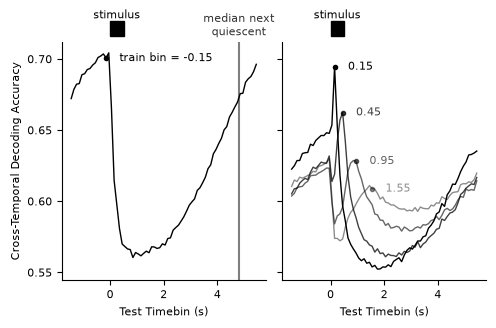

In [98]:
#show baseline and some number of stimulus bins
bin_center_list_baseline=[-0.15]
bin_center_list_stimulus=[0.15,0.45,0.95,1.55]
sel_structure='context_module'

structure_mean_results=(
    consolidated_results.filter(pl.col('structure').eq(sel_structure))
).to_pandas()
cross_temporal_df = pd.DataFrame({
    'session_id': structure_mean_results['session_id'],
    'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

alpha_vals=[1,0.75,0.6,0.45,0.3]

fig,ax=plt.subplots(1, 2, figsize=(5, 3),sharex=True,sharey=True)

for bb, trial_time in enumerate(['baseline', 'stimulus']):
    if trial_time == 'baseline':
        bin_center_list = bin_center_list_baseline
    else:
        bin_center_list = bin_center_list_stimulus

    for bx,sel_bin_center in enumerate(bin_center_list):

        bin_center_ind = np.where(plot_timebins == sel_bin_center)[0][0]
        sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T
        mean_slice=np.nanmean(sel_cross_temporal_slice, axis=0)
        sem_slice=stats.sem(sel_cross_temporal_slice, axis=0, nan_policy='omit')
        line=ax[bb].plot(plot_timebins, mean_slice, label=sel_structure, linewidth=1, color='k', alpha=alpha_vals[bx])
        ax[bb].plot(sel_bin_center, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]], '.', color=line[0].get_color(), alpha=alpha_vals[bx])
        if bb==0:
            ax[bb].text(sel_bin_center+.5, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]],
                        f'train bin = {sel_bin_center:.2f}', color=line[0].get_color(), ha='left', va='center', alpha=alpha_vals[bx])
            ax[bb].axvline(median_next_quiescent,color='black',alpha=0.5)
            # ax[bb].text(median_next_quiescent+.5, 0.7,
            #             f'median next\nquiescent = {median_next_quiescent:.2f}', color='black', ha='left', va='center', alpha=0.5)
        else:
            ax[bb].text(sel_bin_center+.5, mean_slice[np.where(plot_timebins == sel_bin_center)[0][0]],
                        f'{sel_bin_center:.2f}', color=line[0].get_color(), ha='left', va='center', alpha=alpha_vals[bx])
        # ax[bb].fill_between(plot_timebins, mean_slice-sem_slice, mean_slice+sem_slice, color=line[0].get_color(), alpha=0.2)

        ax[bb].spines['top'].set_visible(False)
        ax[bb].spines['right'].set_visible(False)
        ax[bb].set_yticks([0.55,0.6,0.65,0.7])
        ax[bb].set_xlabel('Test Timebin (s)')
    ax[0].set_ylabel('Cross-Temporal Decoding Accuracy')
    #center ylabel across both axes
    # fig.text(0, 0.6, 'Cross-Temporal Decoding Accuracy', va='center', ha='center', rotation='vertical')
    # ax[1].set_xlabel('Test Timebin (s)')

fig.tight_layout()

#get display coords corresponding to 0 seconds and 0.5 seconds
for bb in range(len(ax)):
    fig_coords_0 = ax[bb].transData.transform((0.0, 0))
    fig_coords_05 = ax[bb].transData.transform((0.5, 0))
    fig_coords_0 = fig.transFigure.inverted().transform(fig_coords_0)
    fig_coords_05 = fig.transFigure.inverted().transform(fig_coords_05)

    fig_coords_q = ax[bb].transData.transform((median_next_quiescent, 0))
    fig_coords_q = fig.transFigure.inverted().transform(fig_coords_q)

    #plot a box above both subplots from 0-0.5 seconds
    print(fig_coords_0, fig_coords_05)

    fig.patches.extend([
        plt.Rectangle(
            (fig_coords_0[0], 0.98),  # (x, y)
            fig_coords_05[0]-fig_coords_0[0],        # width
            0.05,       # height
            transform=fig.transFigure,
            color='black',
            # alpha=0.5
        )
    ])

    #plot "stim" above rectangle
    fig.text((fig_coords_0[0]+fig_coords_05[0])/2, 1.03, 'stimulus', ha='center', va='bottom')

    #plot "median next quiescent" above rectangle
    if bb==0:
        fig.text(fig_coords_q[0], 0.97, 'median next\nquiescent', ha='center', va='bottom',alpha=0.8)
    # break

fig.tight_layout()

In [52]:
figsavepath = r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(figsavepath, f"cross_temporal_decoding_slice_{bin_center_list[0]}_{bin_center_list[1]}_separate_axes_side_by_side_multi_timebin_spread_out.png"),dpi=300,pad_inches=0.5)

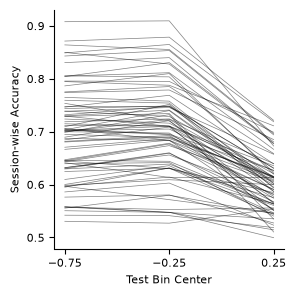

In [11]:
sel_train_bin_center=-0.25
sel_test_bin_centers=[-0.75,-0.25,0.25]
sel_structure='context_module'

train_ind = np.where(plot_timebins == sel_train_bin_center)[0][0]

#get session-wise values for each bin center
structure_mean_results=(
    consolidated_results.filter(pl.col('structure').eq(sel_structure))
).to_pandas()
cross_temporal_df = pd.DataFrame({
    'session_id': structure_mean_results['session_id'],
    'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

session_wise_values=np.full((len(cross_temporal_df.query('length>0')), len(sel_test_bin_centers)), np.nan)

for bb,sel_bin_center in enumerate(sel_test_bin_centers):
    test_ind = np.where(plot_timebins == sel_bin_center)[0][0]
    session_wise_accuracy = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[train_ind,test_ind,:]
    session_wise_values[:,bb] = session_wise_accuracy

fig,ax=plt.subplots(1,1,figsize=(3,3))
ax.plot(sel_test_bin_centers, session_wise_values.T, 'k-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Test Bin Center')
ax.set_ylabel('Session-wise Accuracy')
ax.set_xticks(sel_test_bin_centers)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()

In [12]:
stats.wilcoxon(session_wise_values[:,0], session_wise_values[:,1])

WilcoxonResult(statistic=842.0, pvalue=0.001303827392590193)

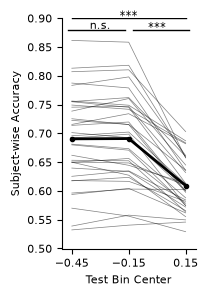

In [96]:
#subject wise analysis

sel_train_bin_center=-0.15
sel_test_bin_centers=[-0.45,-0.15,0.15]
sel_structure='context_module'

train_ind = np.where(plot_timebins == sel_train_bin_center)[0][0]

subject_ids = consolidated_results['subject_id'].unique()

subject_mean_results = []

#loop through each subject
for subject_id in subject_ids:
    subject_results=(
        consolidated_results.filter(pl.col('subject_id').eq(subject_id),pl.col('structure').eq(sel_structure))
    ).to_pandas()
    #take the mean of consolidated results for each subject
    mean_results = np.nanmean(np.dstack(subject_results['cross_temporal_matrix'].apply(np.vstack).values), axis=2)
    subject_mean_results.append(mean_results)

subject_mean_results=np.dstack(subject_mean_results)

subject_wise_values=np.full((subject_mean_results.shape[2], len(sel_test_bin_centers)), np.nan)

for bb,sel_bin_center in enumerate(sel_test_bin_centers):
    test_ind = np.where(plot_timebins == sel_bin_center)[0][0]
    subject_wise_accuracy = subject_mean_results[train_ind,test_ind,:]
    subject_wise_values[:,bb] = subject_wise_accuracy

r01,p01 = stats.wilcoxon(subject_wise_values[:,0], subject_wise_values[:,1])
r12,p12 = stats.wilcoxon(subject_wise_values[:,1], subject_wise_values[:,2])
r02,p02 = stats.wilcoxon(subject_wise_values[:,0], subject_wise_values[:,2])

fig,ax=plt.subplots(1,1,figsize=(2.1,3))
ax.plot(sel_test_bin_centers, subject_wise_values.T, 'k-', linewidth=0.5, alpha=0.5)
ax.plot(sel_test_bin_centers, np.nanmean(subject_wise_values, axis=0), 'k.-', linewidth=2)

ax.plot(np.array(sel_test_bin_centers[:2])-0.02, [0.88,0.88], 'k-', linewidth=1)
ax.plot(np.array(sel_test_bin_centers[1:])+0.02, [0.88,0.88], 'k-', linewidth=1)

ax.plot([sel_test_bin_centers[0], sel_test_bin_centers[2]], [0.9,0.9], 'k-', linewidth=1)

if p01 < 0.001:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[1])/2, 0.875, '***', ha='center',va='bottom')
elif p01 < 0.01:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[1])/2, 0.875, '**', ha='center',va='bottom')
elif p01 < 0.05:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[1])/2, 0.875, '*', ha='center',va='bottom')
elif p01 > 0.05:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[1])/2, 0.877, 'n.s.', ha='center',va='bottom')

if p12 < 0.001:
    ax.text((sel_test_bin_centers[1]+sel_test_bin_centers[2])/2, 0.875, '***', ha='center',va='bottom')
elif p12 < 0.01:
    ax.text((sel_test_bin_centers[1]+sel_test_bin_centers[2])/2, 0.875, '**', ha='center',va='bottom')
elif p12 < 0.05:
    ax.text((sel_test_bin_centers[1]+sel_test_bin_centers[2])/2, 0.875, '*', ha='center',va='bottom')
elif p12 > 0.05:
    ax.text((sel_test_bin_centers[1]+sel_test_bin_centers[2])/2, 0.877, 'n.s.', ha='center',va='bottom')

if p02 < 0.001:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[2])/2, 0.895, '***', ha='center',va='bottom')
elif p02 < 0.01:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[2])/2, 0.895, '**', ha='center',va='bottom')
elif p02 < 0.05:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[2])/2, 0.895, '*', ha='center',va='bottom')
elif p02 > 0.05:
    ax.text((sel_test_bin_centers[0]+sel_test_bin_centers[2])/2, 0.897, 'n.s.', ha='center',va='bottom')

ax.set_xlabel('Test Bin Center')
ax.set_ylabel('Subject-wise Accuracy')
ax.set_xticks(sel_test_bin_centers)
ax.set_ylim([0.5,0.9])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()

In [92]:
# subject_wise_values

In [97]:
figsavepath = r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(figsavepath, f"cross_temporal_decoding_stats_comparison.png"),dpi=300,pad_inches=0.5)

In [ ]:
stats.wilcoxon(subject_wise_values[:,0], subject_wise_values[:,1])

WilcoxonResult(statistic=0.0, pvalue=1.1641532182693481e-10)

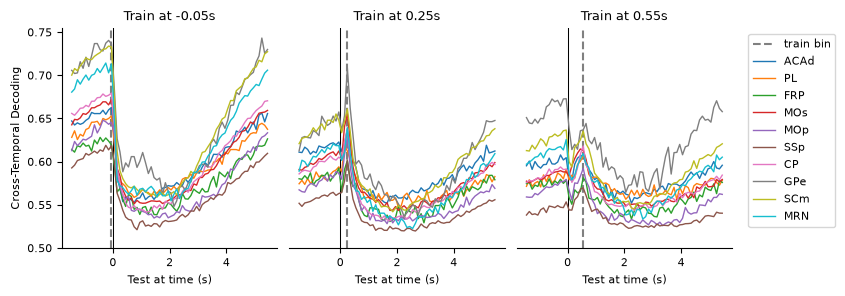

In [ ]:
plot_structures=['ACAd','PL','FRP','MOs','MOp','SSp','CP','GPe','SCm','MRN']
bin_center_list=[-0.05, 0.25, 0.55]

fig,ax=plt.subplots(1, len(bin_center_list), figsize=(10, 3), sharex=True,)
for bb,sel_bin_center in enumerate(bin_center_list):
    ax[bb].axvline(sel_bin_center, color='gray', linestyle='--', label=f'train bin')
    ax[bb].axvline(0, color='k', linewidth=0.75)
    for sel_structure in plot_structures:
        structure_mean_results=(
            consolidated_results.filter(pl.col('structure').eq(sel_structure))
        ).to_pandas()
        cross_temporal_df = pd.DataFrame({
            'session_id': structure_mean_results['session_id'],
            'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
        })
        cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)
        
        bin_center_ind = np.where(plot_timebins == sel_bin_center)[0][0]
        sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T
        ax[bb].plot(plot_timebins, np.nanmean(sel_cross_temporal_slice, axis=0), label=sel_structure, linewidth=1)

    if bb==0:
        ax[bb].set_ylabel('Cross-Temporal Decoding')
    ax[bb].set_xlabel('Test at time (s)')
    ax[bb].set_title(f'Train at {sel_bin_center}s')
    ax[bb].spines['top'].set_visible(False)
    ax[bb].spines['right'].set_visible(False)
    if bb>0:
        ax[bb].spines['left'].set_visible(False)
        ax[bb].set_yticks([])
yranges=[]
for bb in range(len(bin_center_list)):
    yranges.append(ax[bb].get_ylim())
max_ylim = max([y[1] for y in yranges])
for bb in range(len(bin_center_list)):
    ax[bb].set_ylim(0.5,top=max_ylim)
#place legend outside
ax[bb].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [ ]:
savepath=r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(savepath, "cross_temporal_decoding_compare_areas.png"),dpi=300)

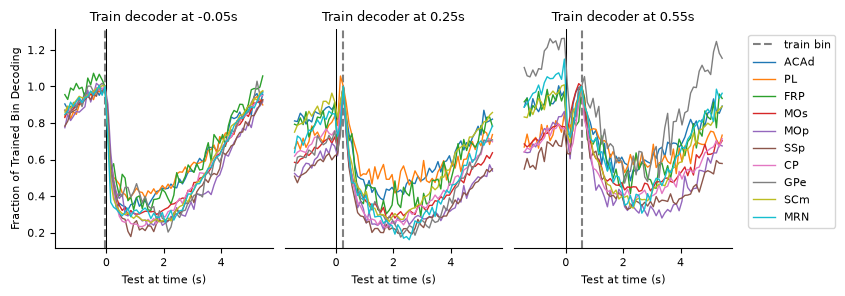

In [ ]:
#normalize between max and 50%

plot_structures=['ACAd','PL','FRP','MOs','MOp','SSp','CP','GPe','SCm','MRN']
bin_center_list=[-0.05, 0.25, 0.55]

fig,ax=plt.subplots(1, len(bin_center_list), figsize=(10, 3), sharex=True)
for bb,sel_bin_center in enumerate(bin_center_list):
    ax[bb].axvline(sel_bin_center, color='gray', linestyle='--', label=f'train bin')
    ax[bb].axvline(0, color='k', linewidth=0.75)
    for sel_structure in plot_structures:
        structure_mean_results=(
            consolidated_results.filter(pl.col('structure').eq(sel_structure))
        ).to_pandas()
        cross_temporal_df = pd.DataFrame({
            'session_id': structure_mean_results['session_id'],
            'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
        })
        cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)
        
        bin_center_ind = np.where(plot_timebins == sel_bin_center)[0][0]
        sel_cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_ind,:,:].T

        mean_cross_temporal_slice = np.nanmean(sel_cross_temporal_slice, axis=0)
        #normalize to trained bin
        normalized_cross_temporal_slice = (mean_cross_temporal_slice - 0.5) / (mean_cross_temporal_slice[bin_center_ind] - 0.5)

        ax[bb].plot(plot_timebins, normalized_cross_temporal_slice, label=sel_structure, linewidth=1)

    if bb==0:
        ax[bb].set_ylabel('Fraction of Trained Bin Decoding')
    ax[bb].set_xlabel('Test at time (s)')
    ax[bb].set_title(f'Train decoder at {sel_bin_center}s')
    ax[bb].spines['top'].set_visible(False)
    ax[bb].spines['right'].set_visible(False)
    if bb>0:
        ax[bb].spines['left'].set_visible(False)
        ax[bb].set_yticks([])
yranges=[]
for bb in range(len(bin_center_list)):
    yranges.append(ax[bb].get_ylim())
max_ylim = max([y[1] for y in yranges])
min_ylim = min([y[0] for y in yranges])
for bb in range(len(bin_center_list)):
    ax[bb].set_ylim(bottom=min_ylim,top=max_ylim)
    #place legend outside
ax[bb].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [ ]:
savepath=r"C:\Users\ethan.mcbride\OneDrive - Allen Institute\quick figures\2026-09-16-cross-temporal-decoding-figs"
fig.savefig(os.path.join(savepath, "cross_temporal_decoding_compare_areas_normalized.png"),dpi=300)

In [ ]:
# quantify the dip

plot_structures=['ACAd','PL','FRP','MOs','MOp','SSp','CP','GPe','SCm','MRN']
bin_center_list=[-0.05, 0.25, 0.55, 1.05, 5.05]

structure_results={
    'structure': [],
    'bin_center_train': [],
    'bin_center_test': [],
    'decoding_accuracy': [],
    'decoding_accuracy_mean': [],
    'decoding_accuracy_sem': [],
    'normalized_decoding_accuracy': [],
    'normalized_decoding_accuracy_mean': [],
    'normalized_decoding_accuracy_sem': [],
    'decoding_accuracy_diff':[],
    'decoding_accuracy_diff_mean':[],
    'decoding_accuracy_diff_sem':[]
}


for sel_structure in plot_structures:
    structure_mean_results=(
        consolidated_results.filter(pl.col('structure').eq(sel_structure))
    ).to_pandas()
    cross_temporal_df = pd.DataFrame({
        'session_id': structure_mean_results['session_id'],
        'cross_temporal_matrix': structure_mean_results['cross_temporal_matrix']
    })
    cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

    for bb_train,sel_bin_center_train in enumerate(bin_center_list):
        for bb_test,sel_bin_center_test in enumerate(bin_center_list):
        
            bin_center_train_ind = np.where(plot_timebins == sel_bin_center_train)[0][0]
            bin_center_test_ind = np.where(plot_timebins == sel_bin_center_test)[0][0]
            sel_train_test_bin = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_train_ind,bin_center_test_ind,:].T

            cross_temporal_slice = np.dstack(cross_temporal_df.query('length>0')['cross_temporal_matrix'].apply(np.vstack).values)[bin_center_train_ind,:,:].T

            norm_cross_temporal_slice = np.full(cross_temporal_slice.shape, np.nan)

            for ii in range(cross_temporal_slice.shape[0]):
                norm_cross_temporal_slice[ii,:] = (cross_temporal_slice[ii,:] - 0.5) / (cross_temporal_slice[ii,bb_train] - 0.5)
            norm_train_test_bin = norm_cross_temporal_slice[:,bb_test]

            decoding_accuracy_diff = cross_temporal_slice[:,bb_train] - cross_temporal_slice[:,bb_test]
            
            structure_results['structure'].append(sel_structure)
            structure_results['bin_center_train'].append(sel_bin_center_train)
            structure_results['bin_center_test'].append(sel_bin_center_test)
            structure_results['decoding_accuracy'].append(sel_train_test_bin)
            structure_results['decoding_accuracy_mean'].append(np.nanmean(sel_train_test_bin))
            structure_results['decoding_accuracy_sem'].append(stats.sem(sel_train_test_bin, nan_policy='omit'))
            structure_results['normalized_decoding_accuracy'].append(norm_train_test_bin)
            structure_results['normalized_decoding_accuracy_mean'].append(np.nanmean(norm_train_test_bin))
            structure_results['normalized_decoding_accuracy_sem'].append(stats.sem(norm_train_test_bin, nan_policy='omit'))
            structure_results['decoding_accuracy_diff'].append(decoding_accuracy_diff)
            structure_results['decoding_accuracy_diff_mean'].append(np.nanmean(decoding_accuracy_diff))
            structure_results['decoding_accuracy_diff_sem'].append(stats.sem(decoding_accuracy_diff, nan_policy='omit'))

structure_results_df=pd.DataFrame(structure_results)
structure_results_df

,structure,bin_center_train,bin_center_test,decoding_accuracy,decoding_accuracy_mean,decoding_accuracy_sem,normalized_decoding_accuracy,normalized_decoding_accuracy_mean,normalized_decoding_accuracy_sem,decoding_accuracy_diff,decoding_accuracy_diff_mean,decoding_accuracy_diff_sem
0,ACAd,-0.05,-0.05,"[0.6944985566853762, 0.7582566246408254, 0.665...",0.662660,0.024844,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.000000,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,0.000000
1,ACAd,-0.05,0.25,"[0.6105630276408455, 0.5522580002593377, 0.617...",0.568681,0.013002,"[0.9116372847765976, 0.876736279369581, 1.2288...",1.094791,0.236033,"[0.019761493386903917, 0.03005424574272364, -0...",0.004668,0.004913
2,ACAd,-0.05,0.55,"[0.6177408351889726, 0.5152820109869217, 0.594...",0.556660,0.011411,"[0.9512228264586472, 0.7780431718723105, 1.110...",0.948592,0.286645,"[0.010908557867787438, 0.05411766757248804, -0...",0.002185,0.004392
3,ACAd,-0.05,1.05,"[0.5793648967180434, 0.5284323185405454, 0.561...",0.563807,0.010713,"[0.8508605961375251, 0.9318907554608132, 0.991...",1.307477,0.274984,"[0.033353630382495725, 0.016606443179412067, 0...",0.003899,0.003768
4,ACAd,-0.05,5.05,"[0.7105638354319248, 0.6879189441444797, 0.640...",0.637172,0.021588,"[0.8988129828104332, 0.8545071955248427, 1.088...",1.112599,0.663154,"[0.022629528370384122, 0.03547415636272244, -0...",0.002474,0.004452
...,...,...,...,...,...,...,...,...,...,...,...,...
245,MRN,5.05,-0.05,"[0.74425544458316, 0.7286807997738028, 0.74954...",0.703830,0.021498,"[0.8360309843148751, 0.8667320410739049, 0.989...",1.051070,0.091070,"[0.03870950453347455, 0.030804214629159055, 0....",0.004415,0.005086
246,MRN,5.05,0.25,"[0.5388036103860073, 0.5689004153831844, 0.563...",0.562953,0.014134,"[1.007697336046008, 0.9028669836394643, 1.0509...",0.811373,0.154807,"[-0.0018171729782217039, 0.022451805427641136,...",0.001232,0.004300
247,MRN,5.05,0.55,"[0.5323914866517863, 0.5704655117572601, 0.556...",0.545941,0.011808,"[0.8911749721732757, 0.9488571981916442, 1.103...",1.036670,0.021636,"[0.025691213003947055, 0.011821399954919376, -...",-0.003681,0.003636
248,MRN,5.05,1.05,"[0.5884361719567711, 0.6061804430191157, 0.621...",0.564431,0.009269,"[0.8122044975465077, 0.9154773987516275, 1.152...",1.035700,0.150014,"[0.04433441783629044, 0.019536971758632338, -0...",0.000518,0.006172


In [ ]:
decoding_accuracy_diff

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [ ]:
#reduce table
sel_train_bin=-0.05
sel_test_bin=1.05

table=structure_results_df.query('bin_center_train==@sel_train_bin and bin_center_test==@sel_test_bin')
table


,structure,bin_center_train,bin_center_test,decoding_accuracy,decoding_accuracy_mean,decoding_accuracy_sem,normalized_decoding_accuracy,normalized_decoding_accuracy_mean,normalized_decoding_accuracy_sem,decoding_accuracy_diff,decoding_accuracy_diff_mean,decoding_accuracy_diff_sem
3,ACAd,-0.05,1.05,"[0.5793648967180434, 0.5284323185405454, 0.561...",0.563807,0.010713,"[0.8508605961375251, 0.9318907554608132, 0.991...",1.307477,0.274984,"[0.033353630382495725, 0.016606443179412067, 0...",0.003899,0.003768
28,PL,-0.05,1.05,"[0.6656716926368453, 0.5816699669368766, 0.635...",0.567847,0.012968,"[0.9886515309410723, 1.4243937776697664, 0.912...",1.186990,0.225680,"[0.0034982477947012036, -0.054329540781042684,...",-0.003506,0.007666
53,FRP,-0.05,1.05,"[0.5072352509572805, 0.609555854483141, 0.5044...",0.546855,0.014099,"[0.9475100656885634, 1.0444227601905465, 1.260...",1.057784,0.055854,"[0.005395315036233139, -0.008740456158601084, ...",-0.002908,0.005918
78,MOs,-0.05,1.05,"[0.56167575222984, 0.501255355982638, 0.527258...",0.551734,0.006752,"[1.022730911753411, 2.311985889275643, 0.76114...",1.203999,0.122315,"[-0.003301696437423174, -0.0016708991249146932...",-0.008032,0.003029
103,MOp,-0.05,1.05,"[0.5336633789862232, 0.5487918839495394, 0.481...",0.542310,0.006964,"[0.77134202466449, 0.9804509006562255, 1.22731...",1.633856,0.398637,"[0.026390805943164564, 0.0026269772217265563, ...",-0.009134,0.004232
128,SSp,-0.05,1.05,"[0.5218388316316179, 0.5112340291484831, 0.481...",0.531409,0.004174,"[1.8992456076372335, 1.0397804732036788, 7.174...",1.251804,0.159950,"[-0.02152010526131043, -0.0074185323365733025,...",-0.009750,0.003344
153,CP,-0.05,1.05,"[0.5995728178204387, 0.5412910314127544, 0.506...",0.544215,0.005302,"[1.2811970058112272, 1.563342194167168, 1.1094...",1.019161,0.043967,"[-0.024156172344490967, -0.03477518632012999, ...",-0.005907,0.002840
178,GPe,-0.05,1.05,"[0.6244254190783383, 0.6385908838545813, 0.608...",0.610554,0.021131,"[0.8988520597699201, 1.0135567911111176, 0.965...",1.064903,0.067634,"[0.019848905982876364, -0.0034318848961132353,...",-0.009958,0.014318
203,SCm,-0.05,1.05,"[0.5991695986078008, 0.6016505640782248, 0.552...",0.568242,0.009399,"[1.0552779791501836, 1.133820200493609, 0.8991...",1.022014,0.030459,"[-0.008690210469236459, -0.02715862527617774, ...",-0.010635,0.003613
228,MRN,-0.05,1.05,"[0.5890676427193281, 0.6039339303397321, 0.632...",0.569048,0.010715,"[0.9837861265047522, 1.1006384640120077, 1.050...",3.558044,2.488692,"[0.0032315981286018536, -0.01825557387757204, ...",-0.009235,0.004999


In [ ]:
#plot select timepoints

min_timebin=-1.5
max_timebin=0

timebins_array=timebins['bin_center'].to_numpy()

timebin_indices=np.where((timebins_array>=min_timebin) & (timebins_array<=max_timebin))[0]

sel_timebins=timebins_array[timebin_indices]
sub_matrix=mean_cross_temporal_matrix[np.ix_(timebin_indices,timebin_indices)]

fig,ax = plt.subplots(figsize=(4,3.25))
im = ax.imshow(sub_matrix, aspect='equal', origin='lower', vmin=0.5, vmax = 0.75,
               extent=[sel_timebins[0]-binsize/2, sel_timebins[-1]+binsize/2, 
                       sel_timebins[0]-binsize/2, sel_timebins[-1]+binsize/2])
ax.vlines([-1,-0.5], ymin=-1.5, ymax=0,color='k', linewidth=0.5)
ax.hlines([-1,-0.5], xmin=-1.5, xmax=0,color='k', linewidth=0.5)
fig.colorbar(im, ax=ax, label='Decoder Accuracy')
ax.set_xlabel('Test Timebin (s)')
ax.set_ylabel('Train Timebin (s)')
ax.set_xticks([-1.5, -1, -0.5, 0])
ax.set_yticks([-1.5, -1, -0.5, 0])